# 01. PyTorch Workflow Fundamentals

In [96]:
import torch
import numpy as np

torch.cuda.is_available()

True

**Covering:**
1. Data preparing and loading
2. Build model
3. Fitting the model to data - training
4. Making predictions and evaluating a model (inference)
5. Saving and loading a model
6. Putting it together 

This imports PyTorch's Neural Network module (nn), which provides the building blocks for creating and training neural networks.

The nn module contains:
- Neural network layers
- Activation functions
- Loss functions
- Model containers
- Utilities for building deep learning models

For example: `nn.Linear`, `nn.Conv2d`, `nn.ReLU`, `nn.GeLU`, `nn.CorssEntropyLoss` 

In [97]:
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.12.0+cu126'

# 1. Data preparing and loading

Create data with linear regression $\to$ X (features) and y (labels).

In [98]:
weights = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # add 1 dim size=1
y = weights * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

## 1.1. Split data into training and test sets

Creating a training and test set (and when required, a validation set).

We can create them by splitting our X and y tensors.

Note: When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn from training data and then evaluate it on test data to get an indication of how well it generalizes to unseen examples.

In [99]:
train_split = int(0.8 * len(X)) # 80:20
print(train_split)
X_train, y_train = X[:train_split], y[:train_split] # from index_0 -> index_train_split
X_test, y_test = X[train_split:], y[train_split:]
X_train.shape, y_train.shape, X_test.shape, y_test.shape


40


(torch.Size([40, 1]),
 torch.Size([40, 1]),
 torch.Size([10, 1]),
 torch.Size([10, 1]))

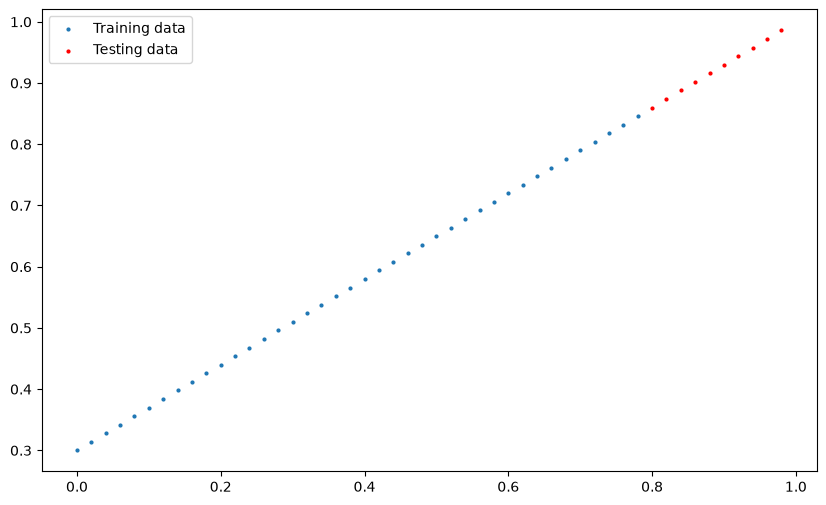

In [121]:
def plot_prediction(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test,
                    predictions=None):
    plt.figure(figsize=(10, 6))
    plt.scatter(train_data, train_labels, s=4, label="Training data")
    plt.scatter(test_data, test_labels, c='red', s=4, label='Testing data')

    if predictions != None:
        plt.scatter(predictions, test_labels, c='green', s=4, label='Predictions')

    plt.legend(prop={'size':10})
    plt.show()
    
plot_prediction()

Almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)

In [101]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

Resource: We'll be using Python classes to create bits and pieces for building neural networks.

Pytorch essential modules:
* `torch.nn`: Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way).
* `torch.nn.Parameter`: Stores tensors that can be used with nn.Module. If requires_grad=True gradients (used for updating model parameters via gradient descent) are calculated automatically, this is often referred to as "autograd".
* `torch.optim`: Contains various optimization algorithms (these tell the model parameters stored in nn.Parameter how to best change to improve gradient descent and in turn reduce the loss).
* `torch.nn.Module`: The base class for all neural network modules, all the building blocks for neural networks are subclasses. If you're building a neural network in PyTorch, your models should subclass nn.Module. Requires a forward() method be implemented.

`def forward()`: All nn.Module subclasses require a forward() method, this defines the computation that will take place on the data passed to the particular nn.Module (e.g. the linear regression formula above).

* `torch.utils.data.Dataset`
* `torch.utils.data.DataLoader`

In [102]:
torch.manual_seed(42) # seed -> hyperparameter

model_0 = LinearRegressionModel()
print(model_0.weights)
print(model_0.bias)

Parameter containing:
tensor([0.3367], dtype=torch.float64, requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)


In [103]:
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.3367], dtype=torch.float64, requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [104]:
model_0.state_dict() # get the state

OrderedDict([('weights', tensor([0.3367], dtype=torch.float64)),
             ('bias', tensor([0.1288]))])

Note: In older PyTorch code, you may also see `torch.no_grad()` being used for inference. While `torch.inference_mode()` and `torch.no_grad()` do similar things, torch.inference_mode() is newer, potentially faster and preferred. See this Tweet from PyTorch for more.

In [105]:
with torch.inference_mode():
    y_preds = model_0.forward(X_test)

In [106]:
y_preds_2 = model_0(X_test)
y_preds # predicted label 

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)

In [107]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)


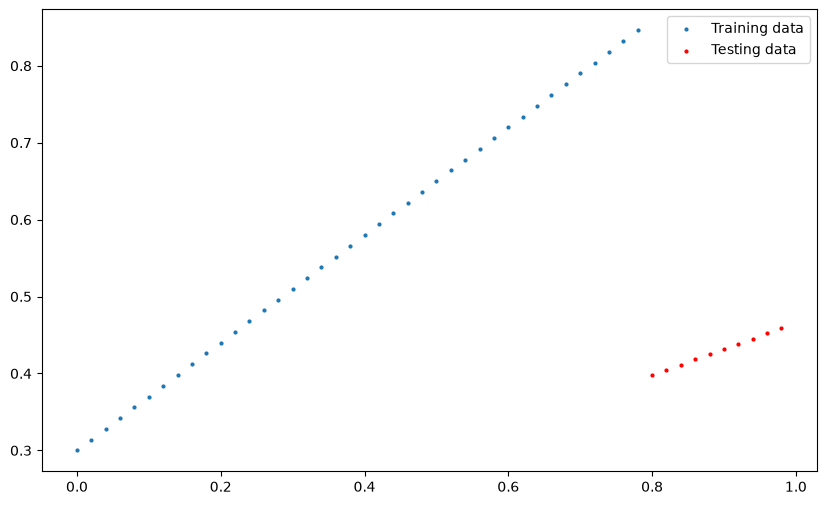

In [108]:
plot_prediction(X_train, y_train, X_test, y_preds)

# 3. Train model

## 3.1. Creating a loss function and optimizer in PyTorch

Loss function:
* Measures how wrong your model's predictions (e.g. y_preds) are compared to the truth labels (e.g. y_test). Lower the better.
* PyTorch has plenty of built-in loss functions in `torch.nn`.
* Mean absolute error (MAE) for regression problems (`torch.nn.L1Loss()`). Binary cross entropy for binary classification problems (`torch.nn.BCELoss()`).


Optimizer:
* Tells your model how to update its internal parameters to best lower the loss.
* You can find various optimization function implementations in `torch.optim`.
* Stochastic gradient descent (`torch.optim.SGD()`). Adam optimizer (`torch.optim.Adam()`).


**Popular loss functions:**
* Classification:
    * Binary cross entropy loss: `nn.BCELoss` or `nn.BCEWithLogitsLoss` for Sigmoid + BCELoss 
    * Multi-class Classification
        * Cross Entropy Loss: `nn.CrossEntropyLoss()`
        * Negative Log Likelihood: `nn.NLLLoss()`

* Regression: 
    * Mean Squared Error: `nn.MSE`
    * Mean Absolute Erros: `nn.L1Loss`
    * Huber Loss: `nn.HuberLoss`
* Cosine Embedding Loss: `nn.CosineEmbeddingLoss`
* Triplet Loss: `nn.TripletMarginLoss`
* Search engine / Recommendation: `nn.MarginRankingLoss`

In [109]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss = |y_true - y_pred|

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), # parameters of target model to optimize
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

## 3.2. Creating an optimization loop in PyTorch 

## 3.3. Training loop


For the training loop, we'll build the following steps:
1. Forward pass: `model(X_train)`
2. Calculate the loss: `loss = loss_fn(y_pred, y_train)`
3. Zero gradients: `optimizer.zero_grad()` 

Note: Mặc định PyTorch sẽ cộng dồn gradient vào .grad của mỗi parameter sau mỗi lần gọi.

grad_new = grad_old + grad_current

4. Perform backpropagation on the loss: `loss.backward()`
5. Update the optimizer (gradient descent): `optimizer.step()`

In [110]:
'''
Quy trình train chuẩn:

for images, labels in dataloader:

    optimizer.zero_grad()   # 1. Xóa gradient cũ

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()         # 2. Tính gradient

    optimizer.step()        # 3. Cập nhật trọng số
'''
w = torch.tensor([2.0], requires_grad=True)

y = w * 3 # dy/dw = 3
y.backward()

print(w.grad)

tensor([3.])


Note: Bên trong `y.backward()` chạy theo trình tự
* Bước 1: Forward Pass -> xây dựng computational graph để tính forward
* Bước 2: Backward Pass -> đạo hàm theo chain rule 

In [111]:
epochs = 20

for epoch in range(epochs):
    # Put model in training mode (this is the default mode, but it's good practice to be explicit)
    model_0.train()

    # 1. Forward pass
    y_preds = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_preds, y_train)

    # 3. Zero the gradients of the optimizer
    optimizer.zero_grad()

    # 4. Backward pass
    loss.backward()

    # 5. Progress/step the optimizer - gradient descent
    optimizer.step()
    print(f"epoch: {epoch} | loss: {loss}")

epoch: 0 | loss: 0.31288135462074396
epoch: 1 | loss: 0.30136034931996125
epoch: 2 | loss: 0.28983934401917866
epoch: 3 | loss: 0.27831833871839606
epoch: 4 | loss: 0.26679733341761336
epoch: 5 | loss: 0.25527632811683076
epoch: 6 | loss: 0.24375532281604814
epoch: 7 | loss: 0.23223431751526552
epoch: 8 | loss: 0.22071331221448287
epoch: 9 | loss: 0.20919230691370022
epoch: 10 | loss: 0.19767130161291763
epoch: 11 | loss: 0.186150296312135
epoch: 12 | loss: 0.17462929101135236
epoch: 13 | loss: 0.16310828571056973
epoch: 14 | loss: 0.15158729531094833
epoch: 15 | loss: 0.14006630491132688
epoch: 16 | loss: 0.12854531451170542
epoch: 17 | loss: 0.117024324112084
epoch: 18 | loss: 0.10609116587642786
epoch: 19 | loss: 0.09681279709394672


## 3.4. Testing loop

As for the testing loop (evaluating our model), the typical steps include:
1. Forward pass: `model(X_test)`
2. Calculate the loss: `loss = loss_fn(y_pred, y_test)`
3. Calulate evaluation metrics (optional)	

In [112]:
# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

In [113]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.0890872000492173 | MAE Test Loss: 0.21729647799466795 
Epoch: 10 | MAE Train Loss: 0.05314849356034055 | MAE Test Loss: 0.1446400721350576 
Epoch: 20 | MAE Train Loss: 0.04543793101588774 | MAE Test Loss: 0.11360938191817808 
Epoch: 30 | MAE Train Loss: 0.041678607941992046 | MAE Test Loss: 0.0991993499781723 
Epoch: 40 | MAE Train Loss: 0.038189304210156275 | MAE Test Loss: 0.08886617943332288 
Epoch: 50 | MAE Train Loss: 0.034760873370757894 | MAE Test Loss: 0.08059368956507082 
Epoch: 60 | MAE Train Loss: 0.03132382100984506 | MAE Test Loss: 0.07232119969681874 
Epoch: 70 | MAE Train Loss: 0.027887402333746047 | MAE Test Loss: 0.06473560338743252 
Epoch: 80 | MAE Train Loss: 0.024458971494347677 | MAE Test Loss: 0.05646311351918045 
Epoch: 90 | MAE Train Loss: 0.021020235356275833 | MAE Test Loss: 0.048190623650928396 


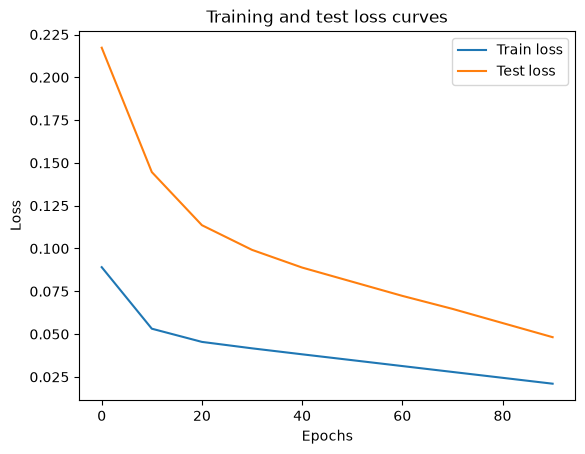

In [114]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [115]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weights}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6126], dtype=torch.float64), 'bias': tensor([0.3368])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## Thử nghiệm

In [116]:
'''
Step-by-step in initialization
1. Init model (trong khởi tạo -> init weights and bias)
2. Create criteria with parameters: loss_function = nn.[loss function]
3. Init optimizer: optimizer = torch.optim.SGD(params=..., lr=...)
'''
torch.manual_seed(42)

model = LinearRegressionModel()
print(list(model.parameters()))
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)
print(loss_fn)

[Parameter containing:
tensor([0.3367], dtype=torch.float64, requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
L1Loss()


In [117]:
# Note: luôn có seed -> kiểm soát random
torch.manual_seed(seed=42)
epochs = 100

# Tracking model
epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range(epochs):
    # Training loop

    # training mode
    model.train()

    # 1. Forward
    y_pred = model(X_train)

    # 2. Calculate the loss 
    train_loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    train_loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    # Testing loop - put the model in evaluation mode
    model.eval()

    with torch.inference_mode():
        # 1. Forward pass
        test_pred = model(X_test)
        # 2. Calculate loss on test data -> valid loss
        test_loss = loss_fn(test_pred, y_test.type(torch.float))

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())

            print(f"Epoch: {epoch} | MAE loss = {train_loss} | MAE Test loss: {test_loss}")

Epoch: 0 | MAE loss = 0.31288135462074396 | MAE Test loss: 0.48106517657284636
Epoch: 10 | MAE loss = 0.19767130161291763 | MAE Test loss: 0.34635512328282925
Epoch: 20 | MAE loss = 0.0890872000492173 | MAE Test loss: 0.21729647799466795
Epoch: 30 | MAE loss = 0.05314849356034055 | MAE Test loss: 0.1446400721350576
Epoch: 40 | MAE loss = 0.04543793101588774 | MAE Test loss: 0.11360938191817808


Epoch: 50 | MAE loss = 0.041678607941992046 | MAE Test loss: 0.0991993499781723
Epoch: 60 | MAE loss = 0.038189304210156275 | MAE Test loss: 0.08886617943332288
Epoch: 70 | MAE loss = 0.034760873370757894 | MAE Test loss: 0.08059368956507082
Epoch: 80 | MAE loss = 0.03132382100984506 | MAE Test loss: 0.07232119969681874
Epoch: 90 | MAE loss = 0.027887402333746047 | MAE Test loss: 0.06473560338743252


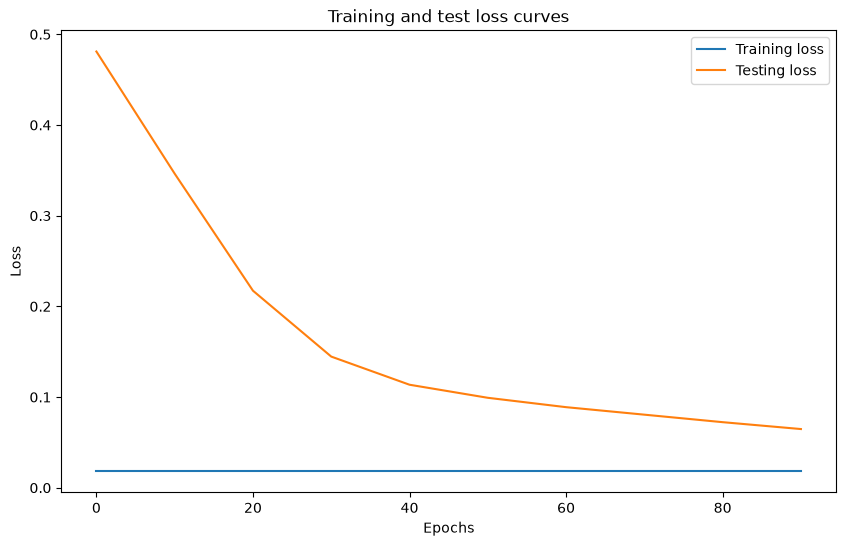

In [118]:
def plot_training(epoch_count, train_loss_values, test_loss_values):
    plt.figure(figsize=(10, 6))
    plt.plot(epoch_count, train_loss_values, label='Training loss')
    plt.plot(epoch_count, test_loss_values, label='Testing loss')
    plt.title("Training and test loss curves")
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.show()

# print(epoch_count)
plot_training(epoch_count, train_loss_values, test_loss_values)

# 4. Making predictions with a trained PyTorch model (inference)

In [119]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]], dtype=torch.float64)

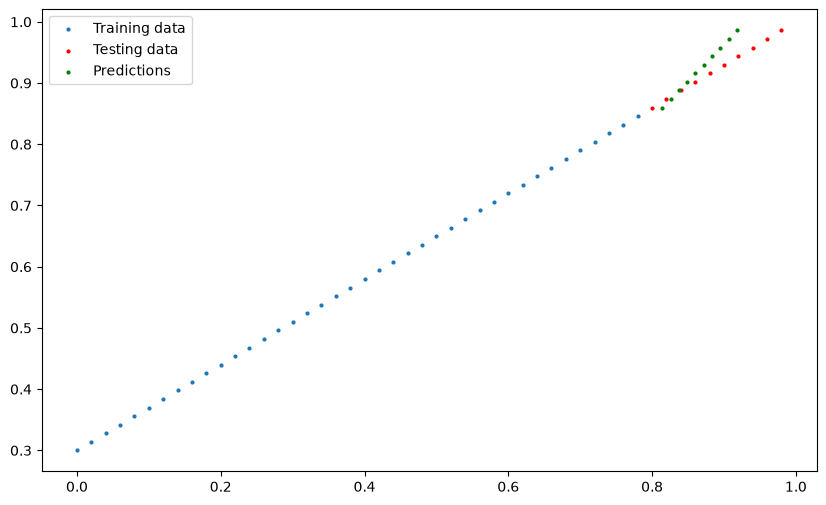

In [122]:
plot_prediction(predictions=y_preds)

# 5. Saving and loading a PyTorch model

`torch.save`: Saves a serialized object to disk using Python's pickle utility. Models, tensors and various other Python objects like dictionaries can be saved using torch.save.

`torch.load`: Uses pickle's unpickling features to deserialize and load pickled Python object files (like models, tensors or dictionaries) into memory. You can also set which device to load the object to (CPU, GPU etc).

`torch.nn.Module.load_state_dict`: Loads a model's parameter dictionary (model.state_dict()) using a saved state_dict() object.

## 5.1. Saving a PyTorch model's state_dict()

Let's see how we can do that in a few steps:

1. We'll create a directory for saving models to called models using Python's pathlib module.
2. We'll create a file path to save the model to.
3. We'll call `torch.save(obj, f)` where obj is the target model's state_dict() and f is the filename of where to save the model.

Sample

In [ ]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models\01_pytorch_workflow_model_0.pth


Practice

In [130]:
import os

print(os.getcwd())
# print(os.listdir())
if 'models' not in os.listdir():
    os.mkdir("models")
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = os.path.join('models', MODEL_NAME)

# Save model
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

d:\University\Projects\Individual projects\Research-training\Pytorch\Labs


## 5.2 Loading a saved PyTorch model's state_dict()

In [131]:
'''
torch.nn.Module.load_state_dict(torch.load(f))

Note: using torch.load() inside torch.nn.Module.load_state_dict() because model formats are different
'''

# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [136]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()
# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # perform a forward pass on the test data with the loaded model
print(loaded_model_preds)
print(y_preds == loaded_model_preds)

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]], dtype=torch.float64)
tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])


# 6. Modeling pipeline

In [138]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.__version__

'2.12.0+cu126'

In [140]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(device)

cuda
